In [1]:
from lib.artificial_data import ArtificialTrackDataset, generate_dataset_with_similarities
from lib.user_similarities import calculate_users_track_common_percentage
from lib.plotting import plot_user_similarities_matrix
from lib.matrix_dataset import MatrixDataset
from lib.spoti import NUMERICAL_FEATURES, PRETTY_PRINT_FEATURES
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
SIMPLIFIED_FEATURES = [
    "danceability",
    "duration_ms",
    "instrumentalness",
    "affinity"
]

In [3]:
df_1 = ArtificialTrackDataset(
    default_value=2,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "owen"},
).randomize()

df_2 = ArtificialTrackDataset(
    default_value=3,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "paul"},
).randomize().insert_some_tracks(df_1, 0.5, 0.5)[0].randomize(["affinity"]).shuffle()

df = df_1.merge(df_2)

display(df.data)

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Final should,owen,0.562542,0.030150,0.226307,0.406315
1,Everything,owen,1.000000,0.586227,1.000000,0.195618
2,Capital care,owen,0.879764,1.000000,0.827882,0.008326
3,Mind reflect,owen,0.156126,0.211695,0.823363,1.000000
4,Assume,owen,0.028944,0.376997,0.097800,0.615619
5,Final should,paul,0.562542,0.030150,0.226307,1.000000
6,Tell current,paul,0.353207,0.503333,0.880949,0.031017
7,Choice body,paul,0.246177,1.000000,0.993295,0.372221
8,Capital care,paul,0.879764,1.000000,0.827882,0.215295
9,Certainly thus,paul,0.040575,0.445980,0.672114,0.696914


In [4]:
df = generate_dataset_with_similarities(
    num_users=100,
    n_samples=500,
    numerical_features=SIMPLIFIED_FEATURES,
    affinity_feature="affinity",
    max_track_mixing_percentage=0.2,
    min_track_mixing_percentage=0.05,
    mix_with_someone_else_chance=0.2,
)
df.data

Mixing user Lori Cook with Joseph Miller with a replacement percentage of 5.80%
Mixing user Dillon Davis with Sandra Richardson with a replacement percentage of 16.40%
Mixing user Brooke Orr with Brian Bowman with a replacement percentage of 5.20%
Mixing user Mark Stanley with Michael Mcguire with a replacement percentage of 19.80%
Mixing user Joshua Davies with Brian Hernandez with a replacement percentage of 5.40%
Mixing user Rhonda Boyd with Lori Cook with a replacement percentage of 17.80%
Mixing user Shawn Mooney with Emily Solomon with a replacement percentage of 11.00%
Mixing user John Martinez with Christina Leonard with a replacement percentage of 13.80%
Mixing user Victoria Goodwin with Matthew Valencia with a replacement percentage of 8.80%
Mixing user Leah James with Ashley Clark with a replacement percentage of 13.40%
Mixing user Kayla Larson with Cory Hernandez with a replacement percentage of 13.20%
Mixing user Russell Schmidt with Richard Morales with a replacement perc

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396
1,Simply some,Matthew Valencia,0.602153,0.281286,0.360737,0.305182
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235
...,...,...,...,...,...,...
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820
49996,Couple leave,Michael Ramirez Jr.,0.596482,0.009788,0.066215,0.061900
49997,Reason early,Michael Ramirez Jr.,0.046132,0.186828,0.395730,0.033652
49998,One send from,Michael Ramirez Jr.,0.315609,0.304490,0.579923,0.100289


In [5]:
df.data.to_csv(os.path.join("data", "artificial_data.csv"))

In [6]:
df_track_common = calculate_users_track_common_percentage(df.data, username_col="username", trackname_col="id")
df_track_common

username,Amanda Hernandez,Amanda Morris,Amy Daniels,Angela Harrington,Angela Obrien,Ann Keller,Ann Reed,Anne Garcia,Anthony Schwartz,Antonio Perry,...,Steven Frey,Steven White,Tara Barry,Timothy Webb,Traci Williamson,Tracy Jones,Victoria Clark,Victoria Goodwin,Wendy Riggs DDS,Zachary Sparks
username,,,,,,,,,,,,,,,,,,,,,
Amanda Hernandez,1.060,0.052,0.034,0.040,0.026,0.052,0.050,0.034,0.056,0.034,...,0.030,0.048,0.050,0.054,0.056,0.058,0.068,0.038,0.046,0.046
Amanda Morris,0.052,1.036,0.040,0.060,0.028,0.040,0.062,0.062,0.056,0.044,...,0.040,0.050,0.044,0.056,0.046,0.058,0.054,0.048,0.046,0.034
Amy Daniels,0.034,0.040,1.036,0.044,0.034,0.028,0.050,0.048,0.056,0.044,...,0.044,0.030,0.046,0.042,0.030,0.064,0.048,0.032,0.038,0.044
Angela Harrington,0.040,0.060,0.044,1.060,0.034,0.046,0.044,0.038,0.054,0.052,...,0.046,0.044,0.066,0.058,0.074,0.040,0.058,0.044,0.030,0.044
Angela Obrien,0.026,0.028,0.034,0.034,1.028,0.040,0.030,0.026,0.018,0.038,...,0.030,0.030,0.034,0.030,0.026,0.036,0.036,0.040,0.024,0.040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tracy Jones,0.058,0.058,0.064,0.040,0.036,0.050,0.058,0.056,0.056,0.038,...,0.040,0.058,0.050,0.032,0.044,1.068,0.078,0.050,0.042,0.052
Victoria Clark,0.068,0.054,0.048,0.058,0.036,0.052,0.032,0.056,0.068,0.046,...,0.026,0.032,0.062,0.050,0.040,0.078,1.068,0.046,0.026,0.060
Victoria Goodwin,0.038,0.048,0.032,0.044,0.040,0.022,0.036,0.030,0.042,0.038,...,0.042,0.038,0.030,0.036,0.052,0.050,0.046,1.032,0.038,0.050


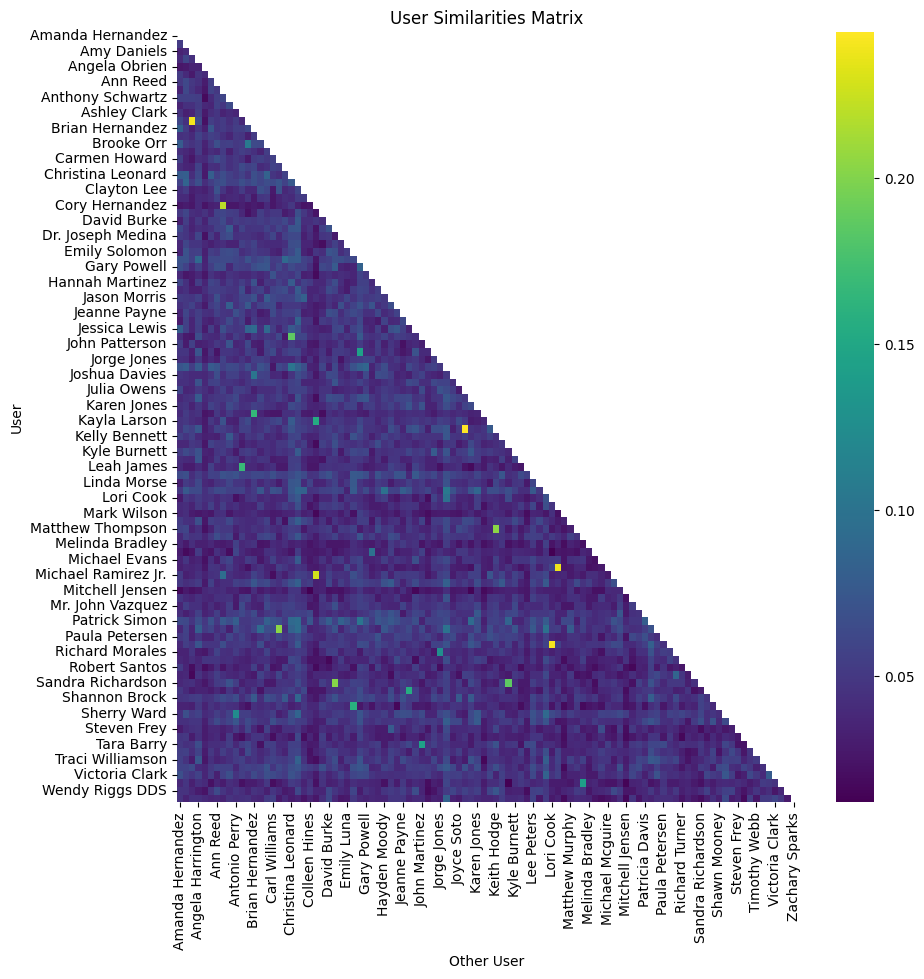

In [7]:
plot_user_similarities_matrix(df_track_common, figsize=(10, 10))

In [8]:
M = MatrixDataset(df.data, user_col="username", item_col="id", value_col="affinity")
M.R.shape

torch.Size([100, 39301])